<a href="https://colab.research.google.com/github/elenann-cpu/Privacy-security-trust-ML-systems/blob/main/Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install sklearn-pandas

import pandas as pd
import numpy as np

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"
!wget $url
!unzip -o bank-additional.zip

df = pd.read_csv('bank-additional/bank-additional-full.csv', sep=';')

print(f"Dataset: ({df.shape[0]}, {df.shape[1]})")
df.head(5)

--2026-06-09 08:14:10--  https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘bank-additional.zip.10’

bank-additional.zip     [  <=>               ] 434.15K  1.50MB/s    in 0.3s    

2026-06-09 08:14:11 (1.50 MB/s) - ‘bank-additional.zip.10’ saved [444572]

Archive:  bank-additional.zip
  inflating: bank-additional/.DS_Store  
  inflating: __MACOSX/bank-additional/._.DS_Store  
  inflating: bank-additional/.Rhistory  
  inflating: bank-additional/bank-additional-full.csv  
  inflating: bank-additional/bank-additional-names.txt  
  inflating: bank-additional/bank-additional.csv  
  inflating: __MACOSX/._bank-additional  
Dataset: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# **Randomized response for binary data and estimation**

Listing 4.1 Randomized response-based algorithm

In [ ]:
import numpy as np

def random_response_bank_housing(response_housing):
    true_ans = (response_housing == 'yes')

    if np.random.randint(0, 2) == 0:
        return true_ans
    else:
        return np.random.randint(0, 2) == 0

Listing 4.2 Playing with the Bank dataset


In [ ]:
housing_data = df['housing']

total_count = len(housing_data)
housing_yes_count = len([i for i in housing_data if i == 'yes'])
housing_no_count = total_count - housing_yes_count

print(f"Total count: {total_count}")
print(f"Housing loan (yes): {housing_yes_count}")
print(f"No housing loan (no): {housing_no_count}")

Total count: 41188
Housing loan (yes): 21576
No housing loan (no): 19612


Listing 4.3 Data Perturbation

In [ ]:
perturbed_housing_yes_count_01 = len([i for i in housing_data if random_response_bank_housing(i)])
print("Epsilon = 0.1")
print("Perturbed YES:", perturbed_housing_yes_count_01)
print("Perturbed NO:", total_count - perturbed_housing_yes_count_01)

print()

perturbed_housing_yes_count_10 = len([i for i in housing_data if random_response_bank_housing(i)])
print("Epsilon = 1.0")
print("Perturbed YES:", perturbed_housing_yes_count_10)
print("Perturbed NO:", total_count - perturbed_housing_yes_count_10)

print()

perturbed_housing_yes_count_50 = len([i for i in housing_data if random_response_bank_housing(i)])
print("Epsilon = 5.0")
print("Perturbed YES:", perturbed_housing_yes_count_50)
print("Perturbed NO:", total_count - perturbed_housing_yes_count_50)

Epsilon = 0.1
Perturbed YES: 21139
Perturbed NO: 20049

Epsilon = 1.0
Perturbed YES: 21017
Perturbed NO: 20171

Epsilon = 5.0
Perturbed YES: 21014
Perturbed NO: 20174


Listing 4.4 Data aggregation and estimation


In [ ]:
import numpy as np

def random_response_aggregation_and_estimation(answers):
    false_yesses = len(answers) / 4
    total_yesses = np.sum([1 if r else 0 for r in answers])
    true_yesses = total_yesses - false_yesses
    rr_result = true_yesses * 2
    return rr_result

answers_01 = [True if random_response_bank_housing(i) else False for i in housing_data]
answers_10 = [True if random_response_bank_housing(i) else False for i in housing_data]
answers_50 = [True if random_response_bank_housing(i) else False for i in housing_data]

estimated_count_01 = random_response_aggregation_and_estimation(answers_01)
estimated_count_10 = random_response_aggregation_and_estimation(answers_10)
estimated_count_50 = random_response_aggregation_and_estimation(answers_50)

print("Epsilon = 0.1")
print(int(estimated_count_01))
print(total_count - int(estimated_count_01))

print()

print("Epsilon = 1.0")
print(int(estimated_count_10))
print(total_count - int(estimated_count_10))

print()

print("Epsilon = 5.0")
print(int(estimated_count_50))
print(total_count - int(estimated_count_50))

Epsilon = 0.1
21446
19742

Epsilon = 1.0
21518
19670

Epsilon = 5.0
21586
19602


# **Direct encoding, perturbation algorithm on categorical data and estimation**

Listing 4.5 Number of people in each occupation domain

In [ ]:
domain = df['job'].dropna().unique()
domain.sort()

print(domain)

['admin.' 'blue-collar' 'entrepreneur' 'housemaid' 'management' 'retired'
 'self-employed' 'services' 'student' 'technician' 'unemployed' 'unknown']


Listing 4.6 Applying direct encoding

In [ ]:
domain = sorted(df['job'].dropna().unique())

def encoding(answer):
    return domain.index(answer)

print(encoding('admin.'))
print(encoding('blue-collar'))
print(encoding('management'))
print(encoding('technician'))

0
1
4
9


Listing 4.7 Perturbation algorithm in direct encoding

In [ ]:
import math
import numpy as np

def perturbation(encoded_ans, epsilon = 5.0):
    d = len(domain)
    p = pow(math.e, epsilon) / (d - 1 + pow(math.e, epsilon))
    q = (1.0 - p) / (d - 1.0)
    s1 = np.random.random()
    if s1 <= p:
        return domain[encoded_ans]
    else:
        s2 = np.random.randint(0, d - 1)
        return domain[(encoded_ans + s2) % d]

# 1. Test using default Epsilon = 5.0 (High accuracy)
print("--- Epsilon = 5.0 ---")
print(perturbation(encoding('admin.')))
print(perturbation(encoding('blue-collar')))
print(perturbation(encoding('management')))
print(perturbation(encoding('technician')))
print()

# 2. Test using Epsilon = 1.0 (Moderate noise)
print("--- Epsilon = 1.0 ---")
print(perturbation(encoding('admin.'), epsilon = 1.0))
print(perturbation(encoding('blue-collar'), epsilon = 1.0))
print(perturbation(encoding('management'), epsilon = 1.0))
print(perturbation(encoding('technician'), epsilon = 1.0))
print()

# 3. Test using Epsilon = 0.1 (Strong noise / high privacy)
print("--- Epsilon = 0.1 ---")
print(perturbation(encoding('admin.'), epsilon = .1))
print(perturbation(encoding('blue-collar'), epsilon = .1))
print(perturbation(encoding('management'), epsilon = .1))
print(perturbation(encoding('technician'), epsilon = .1))

--- Epsilon = 5.0 ---
admin.
blue-collar
management
technician

--- Epsilon = 1.0 ---
entrepreneur
housemaid
student
entrepreneur

--- Epsilon = 0.1 ---
retired
management
unemployed
management


Listing 4.8 Results of direct encoding after perturbation

In [ ]:
# Create a dictionary to hold dataframes for each privacy budget
results_by_epsilon = {}
epsilons = [5.0, 1.0, 0.1]

# Extract clean base data
clean_jobs = df['job'].dropna()

for eps in epsilons:
    # Run perturbation for the specific epsilon value
    perturbed_list = [perturbation(encoding(i), epsilon=eps) for i in clean_jobs]

    # Store the sorted value counts in our dictionary
    results_by_epsilon[f"Epsilon {eps}"] = pd.Series(perturbed_list).value_counts().sort_index()

# Combine everything into a single clean DataFrame for easy side-by-side comparison
comparison_df = pd.DataFrame(results_by_epsilon)
print(comparison_df)

               Epsilon 5.0  Epsilon 1.0  Epsilon 0.1
admin.                9881         4263         3572
blue-collar           8929         4816         4188
entrepreneur          1604         3216         3539
housemaid             1214         2988         3268
management            2978         3467         3573
retired               1843         3236         3537
self-employed         1542         2949         3179
services              3926         3714         3680
student               1051         2719         2876
technician            6520         4362         3871
unemployed            1198         3183         3350
unknown                502         2275         2555


Listing 4.9 Comparison of actual results and perturbed value

In [ ]:
bank_job = df['job'].dropna()
print(bank_job.value_counts().sort_index())

job
admin.           10422
blue-collar       9254
entrepreneur      1456
housemaid         1060
management        2924
retired           1720
self-employed     1421
services          3969
student            875
technician        6743
unemployed        1014
unknown            330
Name: count, dtype: int64


In [ ]:
# 1. Get the baseline true counts
true_counts = df['job'].dropna().value_counts().sort_index()

# 2. Collect the noisy counts across several privacy budgets
epsilons = [5.0, 1.0, 0.1]
clean_jobs = df['job'].dropna()
budget_counts = {}

for eps in epsilons:
    perturbed_list = [perturbation(encoding(i), epsilon=eps) for i in clean_jobs]
    budget_counts[f"perturbed (eps={eps})"] = pd.Series(perturbed_list).value_counts().sort_index()

# 3. Merge everything into a master comparison table
direct_encoding_summary = pd.DataFrame(budget_counts)
direct_encoding_summary.insert(0, "True Counts", true_counts)

print("===== DIRECT ENCODING MULTI-BUDGET EXPERIMENT =====")
print(direct_encoding_summary)

===== DIRECT ENCODING MULTI-BUDGET EXPERIMENT =====
               True Counts  perturbed (eps=5.0)  perturbed (eps=1.0)  \
admin.               10422                 9915                 4430   
blue-collar           9254                 8890                 4753   
entrepreneur          1456                 1606                 3189   
housemaid             1060                 1213                 2884   
management            2924                 3000                 3549   
retired               1720                 1841                 3280   
self-employed         1421                 1536                 2993   
services              3969                 3957                 3747   
student                875                 1011                 2554   
technician            6743                 6522                 4233   
unemployed            1014                 1184                 3226   
unknown                330                  513                 2350   

           

Listing 4.10 Applying aggregation and estimation to direct encoding

In [ ]:
def aggregation_and_estimation(answers, epsilon = 5.0):
    n = len(answers)
    d = len(domain)
    p = pow(math.e, epsilon) / (d - 1 + pow(math.e, epsilon))
    q = (1.0 - p) / (d - 1.0)

    aggregator = answers.value_counts().reindex(domain, fill_value=0)
    return [max(int((i - n*q) / (p-q)), 0) for i in aggregator]

clean_jobs = df['job'].dropna()
true_counts = clean_jobs.value_counts().reindex(domain, fill_value=0)

final_table_data = {
    "Original Value": true_counts.values
}

epsilons = [5.0, 1.0, 0.1]

for eps in epsilons:
    perturbed_list = [perturbation(encoding(i), epsilon=eps) for i in clean_jobs]
    perturbed_answers = pd.Series(perturbed_list)

    final_table_data[f"Estimated (eps={eps})"] = aggregation_and_estimation(perturbed_answers, epsilon=eps)

table_4_2_clean = pd.DataFrame(final_table_data, index=domain)

print("\n===== Table 4.2: Number of people in each profession, before and after aggregation and estimation =====")
print(table_4_2_clean.to_string())


===== Table 4.2: Number of people in each profession, before and after aggregation and estimation =====
               Original Value  Estimated (eps=5.0)  Estimated (eps=1.0)  Estimated (eps=0.1)
admin.                  10422                10372                10918                30787
blue-collar              9254                 9287                14319                74525
entrepreneur             1456                 1484                 1968                    0
housemaid                1060                 1043                  427                    0
management               2924                 2939                 3860                 2127
retired                  1720                 1738                 2104                 1782
self-employed            1421                 1432                    0                    0
services                 3969                 3986                 5249                33550
student                   875                  838        

# **Histogram encoding and thresholding on numerical data and estimation**

Listing 4.13 Histogram encoding

[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
 0.0]
------------------------------


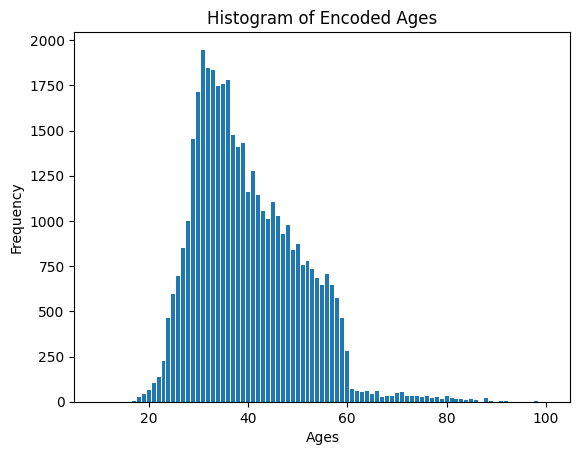

In [ ]:
import matplotlib.pyplot as plt

domain = np.arange(10, 101)

def encoding(answer):
    return [1.0 if d == answer else 0.0 for d in domain]

primer_11 = encoding(11)

print("[", end="")
for i, val in enumerate(primer_11):
    suffix = ", " if i < len(primer_11) - 1 else ""
    print(f"{val}", end=suffix)
    if (i + 1) % 15 == 0:
        print("\n ", end="")
print("]")
print("-" * 30)

age = df['age']
answers = np.sum([encoding(r) for r in age], axis=0)

plt.bar(domain, answers)
plt.xlabel("Ages")
plt.ylabel("Frequency")
plt.title("Histogram of Encoded Ages")
plt.show()

Listing 4.14 Summation with histogram encoding

In [ ]:
def she_perturb_bit(bit, epsilon=5.0):
    return bit + np.random.laplace(loc=0, scale=2 / epsilon)

def she_perturbation(encoded_ans, epsilon=5.0):
    return [she_perturb_bit(b, epsilon) for b in encoded_ans]

def short_print(vec, title, k=6):
    print(title)
    print("[")
    for i in range(k):
        print(vec[i], end=", ")
    print("..., ")
    for i in range(-k, 0):
        end = ", " if i != -1 else ""
        print(vec[i], end=end)
    print("\n]")
    print("-" * 60)

short_print(she_perturbation(encoding(11), epsilon=5.0), "Epsilon = 5.0:")
short_print(she_perturbation(encoding(11), epsilon=1.0), "Epsilon = 1.0:")
short_print(she_perturbation(encoding(11), epsilon=0.1), "Epsilon = 0.1:")

she_estimated_answers = np.sum(
    [she_perturbation(encoding(r), epsilon=5.0) for r in age],  # fixed here
    axis=0
)


Epsilon = 5.0:
[
0.09433039197127012, 0.5593306714822381, -0.3730155879937213, -0.1142975634410997, 0.12288696119825977, 0.3769076150877997, ..., 
-0.03715645333488108, -0.009170855097244149, 0.17598438317624057, 0.2359037240017127, -0.17374875759949718, -0.13494028316316306
]
------------------------------------------------------------
Epsilon = 1.0:
[
8.201197134843069, 4.6490069859175165, 1.225380618785873, 1.947016607200996, -4.2844565544046675, 5.4744747517960075, ..., 
-1.2534455690518767, 1.0915282339843673, -2.56748683057136, 0.06505833051188921, 3.6575053143521945, -0.6595382386979346
]
------------------------------------------------------------
Epsilon = 0.1:
[
-17.638873691901665, -12.412909719452735, 29.985526044462812, -20.92129004192593, 0.20560381341201694, -14.403061595323072, ..., 
-22.823554174943567, -39.447360827725035, -10.828083137365228, 10.506365875602508, -15.508768370565619, -10.836398824290427
]
------------------------------------------------------------


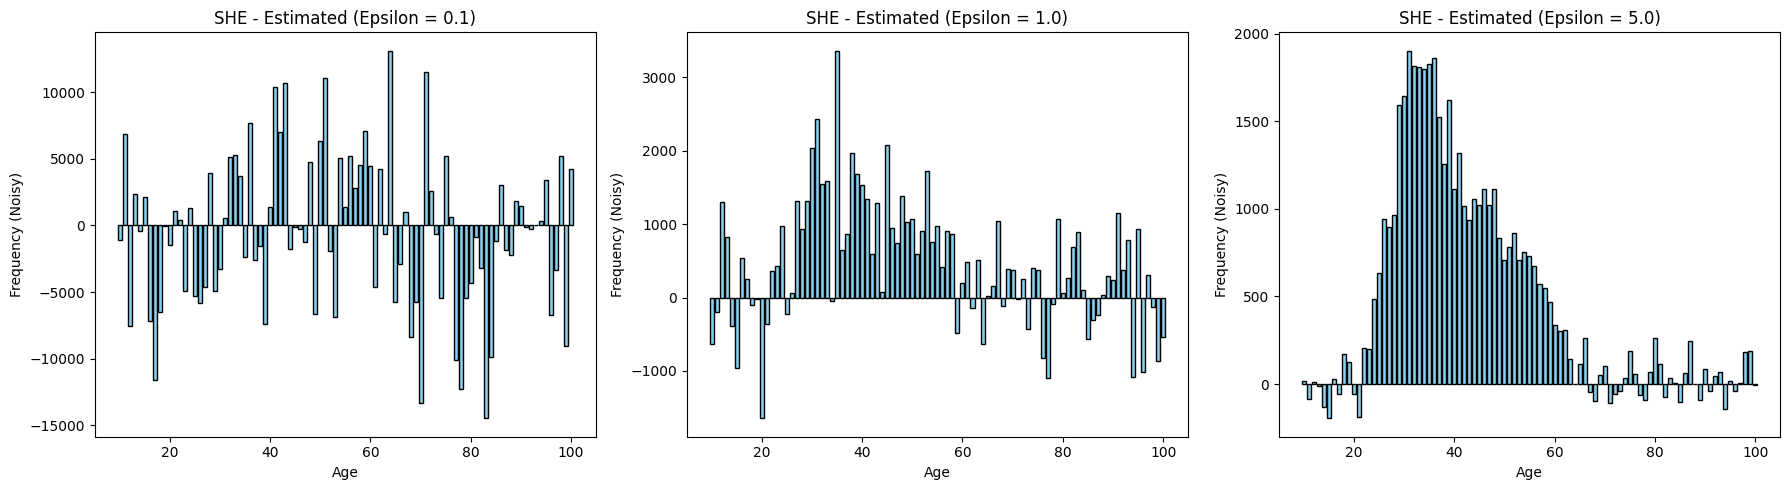

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

epsilon_values = [0.1, 1.0, 5.0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, eps in enumerate(epsilon_values):
    she_estimated_answers = np.sum(
        [she_perturbation(encoding(r), epsilon=eps) for r in df['age']],
        axis=0
    )

    axes[i].bar(domain, she_estimated_answers, color='skyblue', edgecolor='black')
    axes[i].set_xlabel("Age")
    axes[i].set_ylabel("Frequency (Noisy)")
    axes[i].set_title(f"SHE - Estimated (Epsilon = {eps})")

plt.tight_layout()
plt.show()

Listing 4.15 Thresholding with histogram encoding

Epsilon = 5.0:
[
0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ..., 
0.0, 0.0, 0.0, 0.0, 0.0, 0.0
]
------------------------------------------------------------
Epsilon = 1.0:
[
0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ..., 
0.0, 0.0, 0.0, 0.0, 0.0, 0.0
]
------------------------------------------------------------
Epsilon = 0.1:
[
0.0, 1.0, 0.0, 1.0, 1.0, 0.0, ..., 
1.0, 0.0, 0.0, 1.0, 0.0, 1.0
]
------------------------------------------------------------


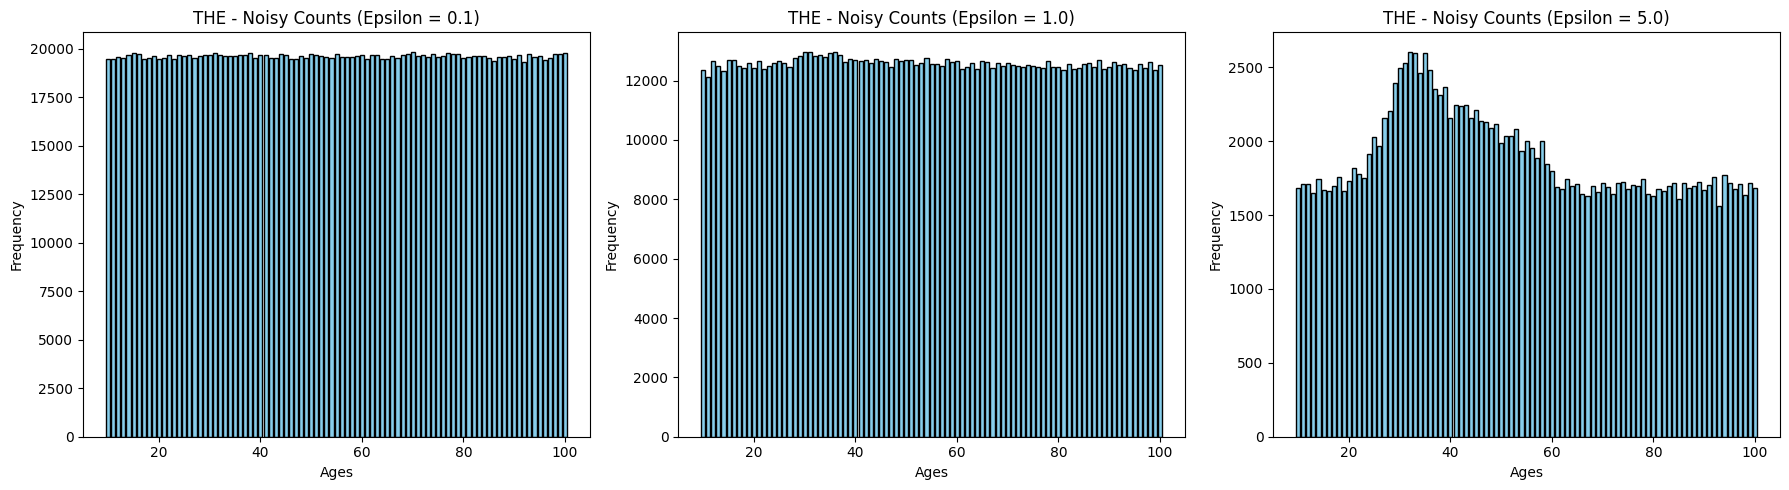

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. ДЕФИНИРАЊЕ НА ФУНКЦИИТЕ ЗА ПЕРТУРБАЦИЈА
def the_perturb_bit(bit, epsilon=5.0, theta=1.0):
    val = bit + np.random.laplace(loc=0, scale=2 / epsilon)
    return 1.0 if val > theta else 0.0

def the_perturbation(encoded_ans, epsilon=5.0, theta=1.0):
    return [the_perturb_bit(b, epsilon, theta) for b in encoded_ans]

# 2. ФУНКЦИЈА ЗА КРАТОК ПРИНТ НА ВЕКТОРОТ
def short_print(vec, title, k=6):
    print(title)
    print("[")
    for i in range(k):
        print(vec[i], end=", ")
    print("..., ")
    for i in range(-k, 0):
        end = ", " if i != -1 else ""
        print(vec[i], end=end)
    print("\n]")
    print("-" * 60)

# 3. ИСПИШУВАЊЕ НА ТЕКСТУАЛНИТЕ РЕЗУЛТАТИ (за пример возраст 11)
short_print(the_perturbation(encoding(11), epsilon=5.0), "Epsilon = 5.0:")
short_print(the_perturbation(encoding(11), epsilon=1.0), "Epsilon = 1.0:")
short_print(the_perturbation(encoding(11), epsilon=0.1), "Epsilon = 0.1:")

# 4. ПОДГОТОВКА И ЦРТАЊЕ НА ГРАФИКОНИТЕ (со skyblue боја)
epsilon_values = [0.1, 1.0, 5.0]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, eps in enumerate(epsilon_values):
    the_perturbed_answers = np.sum(
        [the_perturbation(encoding(r), epsilon=eps, theta=1.0) for r in df['age']],
        axis=0
    )

    axes[i].bar(domain, the_perturbed_answers, color='skyblue', edgecolor='black')
    axes[i].set_xlabel("Ages")
    axes[i].set_ylabel("Frequency")
    axes[i].set_title(f"THE - Noisy Counts (Epsilon = {eps})")

plt.tight_layout()
plt.show()

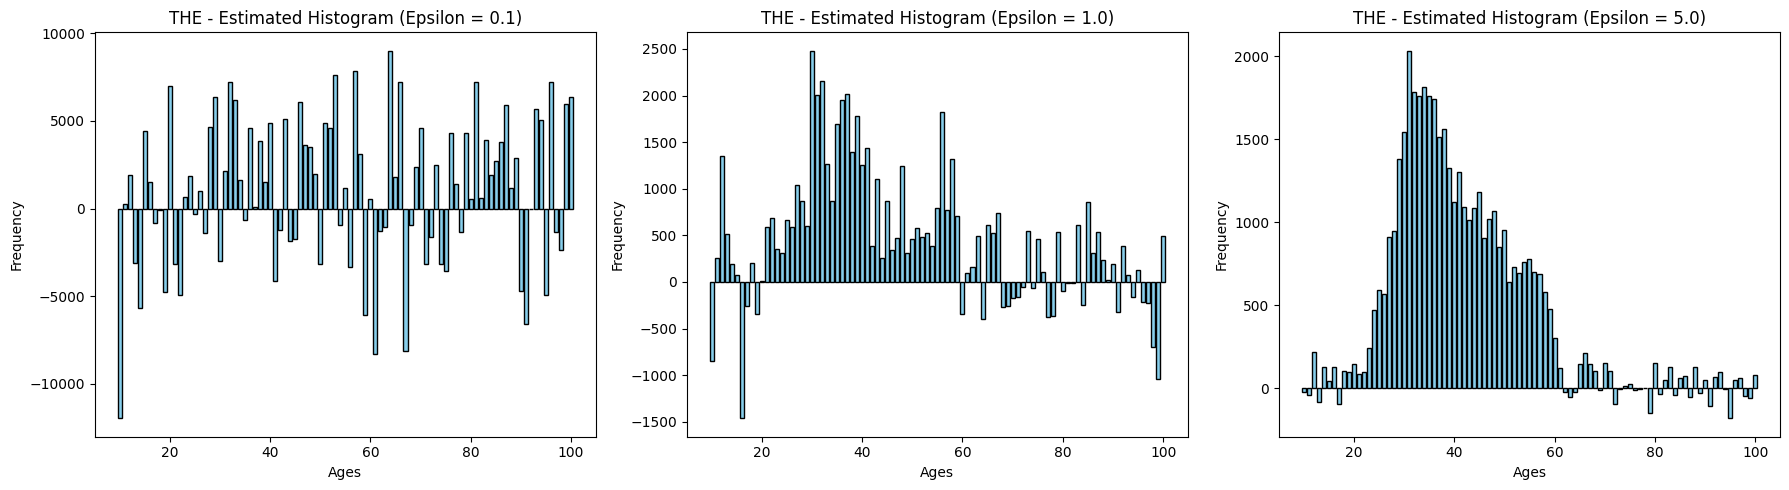

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math

def the_aggregation_and_estimation(answers, epsilon=5.0, theta=1.0):
    p = 1 - 0.5 * pow(math.e, epsilon / 2 * (1.0 - theta))
    q = 0.5 * pow(math.e, epsilon / 2 * (0.0 - theta))
    sums = np.sum(answers, axis=0)
    n = len(answers)
    return [int((i - n * q) / (p - q)) for i in sums]

epsilon_values = [0.1, 1.0, 5.0]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, eps in enumerate(epsilon_values):
    the_perturbed_answers = [
        the_perturbation(encoding(r), epsilon=eps, theta=1.0) for r in df['age']
    ]

    estimated_answers = the_aggregation_and_estimation(
        the_perturbed_answers,
        epsilon=eps,
        theta=1.0
    )

    axes[i].bar(domain, estimated_answers, color='skyblue', edgecolor='black')
    axes[i].set_xlabel("Ages")
    axes[i].set_ylabel("Frequency")
    axes[i].set_title(f"THE - Estimated Histogram (Epsilon = {eps})")

plt.tight_layout()
plt.show()